<a href="https://colab.research.google.com/github/tala116/personal-resume/blob/main/Lab_05_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CECS 416 – Applied Machine Learning
## Lab 05: Logistic Regression

**University of Jeddah — College of Computer Science and Engineering**
**Department of Computer Science and Artificial Intelligence**

---

## Student Information
- **Name:** _________tala arjan zamreeg_____________________
- **Student ID:** ___2116462
_____________________
- **Section:** ___________________________
- **Date:** ______________________________

---

## Lab Information

### Lab Description
Last week you *saw* the breast-cancer data: PCA squeezed 30 measurements into a 2D picture and two clouds appeared. **Today a model learns to separate them** — and to say *how sure it is*.

**Logistic regression** predicts **probabilities** for classes: a linear score squashed through the **sigmoid** into (0, 1). That probability, plus a **threshold you choose**, becomes the prediction — and choosing that threshold is a real decision with real costs (in medicine: a missed cancer vs. a false alarm).

Two real applications:
- 🩺 **Tutorial:** breast cancer diagnosis (built into sklearn — 569 real tumors)
- ☎️ **Homework:** the **UCI Bank Marketing** data — 41,188 real phone calls from a Portuguese bank's campaign (`marketing.csv`)

---

### Lab Objectives
By the end of this lab, you will be able to:

- Compute the **sigmoid** by hand and explain what logistic regression outputs
- Use **`stratify=y`** in train/test splits and say why it matters
- Read **`predict_proba`** correctly (and avoid the column trap)
- Build and interpret a **confusion matrix** (TN/FP/FN/TP) in real-world terms
- Treat the **threshold as a choice** driven by error costs
- Read scaled **coefficients as evidence** for/against a class
- Recognize **target leakage** in a real case (homework B5)

---

### Course Learning Outcome (CLO) Mapping

**CLO 2.1 (Skill S3):**
*Integrate open-source/commercial Machine Learning libraries to develop solutions for practical problems.*

---

### Assessment (Mark: 1)

| Mark | Criteria |
|------|----------|
| **1.0** | Attended the lab **and** submitted a notebook that runs top-to-bottom with all homework tasks attempted correctly |
| **0.5** | Attended **or** submitted, with partial correctness or incomplete tasks |
| **0.0** | Did not attend and did not submit, or notebook does not run |

---

### Instructions
- Answer all questions directly in this notebook — **Quick Check** answers go in the marked cells.
- Do **not** modify the required structure of the lab.
- Ensure the notebook runs **top-to-bottom without errors**.
- Homework is due **before the next lab session**.

---

## 📥 Setup

The tutorial uses sklearn's built-in breast cancer data — nothing to upload yet.
📂 For the **homework**, upload `marketing.csv`.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
print("✅ Ready")

✅ Ready


---
## 📘 Part 1: The Sigmoid — Turning a Score into a Probability

Linear regression outputs any number (−∞, +∞). For classification we want a **probability** in (0, 1). The **sigmoid** does the squashing:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where z is a linear score (weights · features + bias), exactly like Lab 04's regression — logistic regression is *linear regression wearing a sigmoid*.

σ(-3) = 0.047
σ(-2) = 0.119
σ(-1) = 0.269
σ(+0) = 0.500
σ(+1) = 0.731
σ(+2) = 0.881
σ(+3) = 0.953


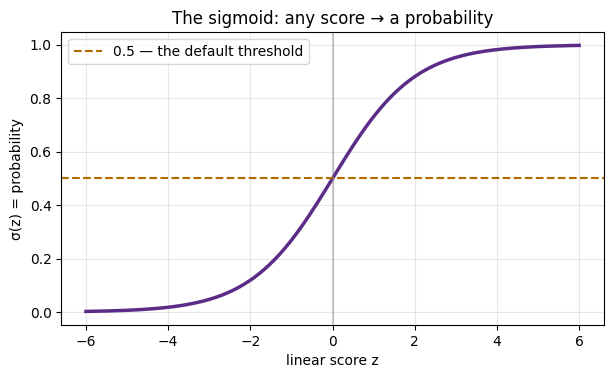

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-3, -2, -1, 0, 1, 2, 3]:
    print(f"σ({z:+d}) = {sigmoid(z):.3f}")

zz = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 3.8))
plt.plot(zz, sigmoid(zz), color='#5B2C87', linewidth=2.5)
plt.axhline(0.5, color='#B26A00', linestyle='--', label='0.5 — the default threshold')
plt.axvline(0, color='gray', alpha=0.4)
plt.xlabel('linear score z'); plt.ylabel('σ(z) = probability')
plt.title('The sigmoid: any score → a probability')
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Landmarks worth memorizing:** σ(0) = 0.5 (the fence), σ(±2) ≈ 0.88 / 0.12, and the curve saturates — beyond |z| ≈ 4 it's essentially decided.

### ✏️ Quick Check 1
Compute σ(0) and σ(2) **by hand** (show the fraction for σ(2) with e⁻² ≈ 0.135).


​
 ≈0.881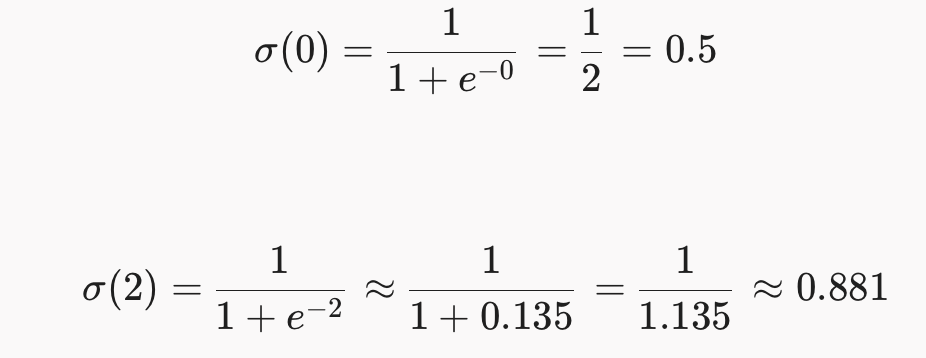

---
## 📘 Part 2: The Data — and a New Splitting Rule

### 🔧 Data Preparation

sklearn's breast cancer dataset labels **benign = 1**. Medically we care about *detecting disease*, so we **relabel malignant = 1** — then a False Negative means a **missed cancer**, and every metric reads the medical way. (Watch for this in real projects: *know which class is 1 before you interpret anything.*)

In [24]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = 1 - cancer.target                     # relabel: malignant = 1  (sklearn default: benign = 1)

print("Shape:", X.shape)
print("Class balance:", np.bincount(y), "→ malignant fraction:", round(y.mean(), 3))

Shape: (569, 30)
Class balance: [357 212] → malignant fraction: 0.373


### New processing skill: `stratify=y`

`train_test_split` deals rows **randomly** — so by luck, the test set's class mix can drift from the real one, and every metric you compute inherits the distortion. `stratify=y` forces train *and* test to mirror the full data's ratio:

In [25]:
# both ways, side by side
Xtr_s_, Xte_s_, ytr_s_, yte_s_ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
Xtr_n_, Xte_n_, ytr_n_, yte_n_ = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"malignant fraction — full data:      {y.mean():.3f}")
print(f"WITH stratify=y   — train / test:    {ytr_s_.mean():.3f} / {yte_s_.mean():.3f}   ← mirrors the full ratio")
print(f"without stratify  — train / test:    {ytr_n_.mean():.3f} / {yte_n_.mean():.3f}   ← drifted by luck")

# keep the stratified split
X_train, X_test, y_train, y_test = Xtr_s_, Xte_s_, ytr_s_, yte_s_

malignant fraction — full data:      0.373
WITH stratify=y   — train / test:    0.374 / 0.368   ← mirrors the full ratio
without stratify  — train / test:    0.371 / 0.377   ← drifted by luck


Here the drift is mild (37% malignant is fairly balanced). On **imbalanced** data — like the homework's 11% subscribers — an unlucky split visibly shifts the minority class. **Rule from now on: classification splits are stratified.** (Lab 07's cross-validation will do stratified folds automatically.)

### ✏️ Quick Check 2
In your own words: what does `stratify=y` guarantee, and why does it matter more on imbalanced data?

stratify=y guarantees that both the train and test sets have the same class proportions as the original dataset.
It matters more on imbalanced data because random splitting might accidentally give the test set very few samples of the minority class, which would distort our evaluation metrics.

---
## 📘 Part 3: Fit, and Read the *Probabilities*

In [26]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)     # fit on TRAIN only — the Lab 03 rule
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000).fit(X_train_s, y_train)

proba = model.predict_proba(X_test_s)         # shape (n, 2): [P(benign), P(malignant)]
print("First 5 patients, [P(benign), P(malignant)]:")
print(proba[:5].round(3))

p_malignant = proba[:, 1]                     # ⚠️ column 1 = P(class 1) = P(malignant)
print("\nP(malignant), first 5:", p_malignant[:5].round(3))

First 5 patients, [P(benign), P(malignant)]:
[[1.    0.   ]
 [0.    1.   ]
 [0.957 0.043]
 [0.424 0.576]
 [0.491 0.509]]

P(malignant), first 5: [0.    1.    0.043 0.576 0.509]


### ✏️ Quick Check 3
What exactly is `predict_proba(X)[:, 1]` here — and what silently goes wrong if you read column `[:, 0]` instead?

It represents the predicted probability of the positive class (class 1), which is
P(malignant)
. If we accidentally read [:, 0], we would be looking at
P(benign)
, which would silently flip all our predictions and make the model treat malignant tumors as benign and vice versa.

---
## 📘 Part 4: The Confusion Matrix — Naming the Mistakes

A probability + a threshold = a prediction. At the default **0.5**:

In [27]:
y_pred = (p_malignant >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix (rows = truth, cols = prediction):")
print(pd.DataFrame(cm, index=['True: benign', 'True: MALIGNANT'],
                       columns=['Pred: benign', 'Pred: MALIGNANT']))
print(f"\nTN={tn}  correctly cleared")
print(f"FP={fp}   false alarm  (healthy patient sent for biopsy)")
print(f"FN={fn}   ⚠️ MISSED CANCER — the error that can cost a life")
print(f"TP={tp}  correctly caught")

Accuracy: 0.965

Confusion matrix (rows = truth, cols = prediction):
                 Pred: benign  Pred: MALIGNANT
True: benign               71                1
True: MALIGNANT             3               39

TN=71  correctly cleared
FP=1   false alarm  (healthy patient sent for biopsy)
FN=3   ⚠️ MISSED CANCER — the error that can cost a life
TP=39  correctly caught


96.5% accurate — but the number that matters medically is **FN = 3**: three malignant tumors called benign. Can we trade for fewer misses? **Lower the threshold** — flag anything with even moderate probability:

In [28]:
y_pred_30 = (p_malignant >= 0.3).astype(int)
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, y_pred_30).ravel()

print(f"{'threshold':>10s} {'FN (missed)':>12s} {'FP (alarms)':>12s} {'accuracy':>9s}")
print(f"{'0.5':>10s} {fn:>12d} {fp:>12d} {accuracy_score(y_test, y_pred):>9.3f}")
print(f"{'0.3':>10s} {fn3:>12d} {fp3:>12d} {accuracy_score(y_test, y_pred_30):>9.3f}")

 threshold  FN (missed)  FP (alarms)  accuracy
       0.5            3            1     0.965
       0.3            1            1     0.982


Missed cancers drop **3 → 1**. The price: more false alarms. Neither threshold is "correct" — it's a **decision about which error costs more**, made by people, not by sklearn's default.

### ✏️ Quick Check 4
For cancer screening, what happens to FN and FP when the threshold drops from 0.5 to 0.3 — and who should choose the threshold?

It represents the predicted probability of the positive class (class 1), which is
P(malignant)
. If we accidentally read [:, 0], we would be looking at
P(benign)
, which would silently flip all our predictions and make the model treat malignant tumors as benign and vice versa.


---
## 📘 Part 5: Coefficients as Evidence

Because we scaled, the coefficients are comparable — each is the weight of one measurement's evidence:

Strongest evidence toward MALIGNANT (largest +):
worst symmetry    1.06
radius error      1.23
worst texture     1.43

Strongest evidence toward benign (largest −):
compactness error         -0.91
fractal dimension error   -0.59
mean compactness          -0.44


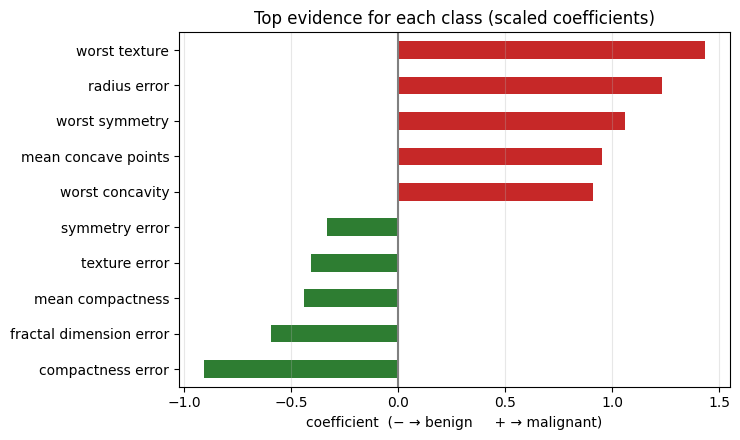

In [29]:
coefs = pd.Series(model.coef_[0], index=cancer.feature_names).sort_values()

print("Strongest evidence toward MALIGNANT (largest +):")
print(coefs.tail(3).round(2).to_string())
print("\nStrongest evidence toward benign (largest −):")
print(coefs.head(3).round(2).to_string())

plt.figure(figsize=(7.5, 4.5))
pd.concat([coefs.head(5), coefs.tail(5)]).plot(kind='barh',
    color=['#2E7D32']*5 + ['#C62828']*5)
plt.axvline(0, color='gray')
plt.title('Top evidence for each class (scaled coefficients)')
plt.xlabel('coefficient  (− → benign     + → malignant)')
plt.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

### ✏️ Quick Check 5
The largest positive coefficient is `worst texture` (≈ +1.4). Read it as a sentence of *evidence*.

A higher value of worst texture provides strong evidence that increases the linear score and probability toward classifying the tumor as malignant.

---

## 📝 Lab Homework

### Part A: Concept + Hand Work

**A1.** Compute σ(z) **by hand** for z = −2, 0, 1, 3 (3 decimals; use e⁻² ≈ 0.135, e⁻¹ ≈ 0.368, e⁻³ ≈ 0.050). Then verify all four with your `sigmoid` function in code.

In [30]:
for z in [-2, 0, 1, 3]:
    print(f"σ({z:+d}) = {sigmoid(z):.3f}")

σ(-2) = 0.119
σ(+0) = 0.500
σ(+1) = 0.731
σ(+3) = 0.953


**A2.** A tumor receives P(malignant) = 0.62. What does the model predict at threshold 0.5? At exactly what threshold value does the prediction flip to benign?

At threshold 0.5, the model predicts malignant because
P(malignant)=0.62≥0.5
.
The prediction flips to benign at any threshold value strictly greater than 0.62 (i.e.,
threshold>0.62
, because at exactly
0.62
 it is still classified as malignant under the rule
p≥threshold
).

**A3.** Both kNN (Lab 03) and logistic regression benefit from scaling — but for **different reasons**. Explain each in one sentence.

kNN: Scaling is necessary because it relies on distance calculations (like Euclidean distance), so features with larger ranges would otherwise completely dominate the neighborhood search.   
IPYNB
Logistic Regression: Scaling is necessary so that the learned coefficients can be directly compared as meaningful weights of evidence for each feature, and it also helps the optimization algorithm converge faster.

---
### Part B: Transfer Task — Bank Marketing Data ☎️

> 📂 **Upload:** `marketing.csv`
> 🎯 **Goal:** predict `y` — did the customer subscribe to a term deposit after the marketing call?
> 📖 **About:** the **UCI Bank Marketing** dataset — **41,188 real phone calls** from a Portuguese bank's campaigns (Moro, Cortez & Rita, 2014). One row = one customer call.
>
> ⚠️ **Real-world quirk #1:** the file is **semicolon-separated** (European CSV convention) — `pd.read_csv('marketing.csv', sep=';')`. Plain `read_csv` gives you one giant column.
>
> 📤 **Upload check:** the file is **~5.8 MB — wait for Colab's upload progress circle to finish** before running. If you see `ParserError: ... EOF inside string`, your copy is incomplete: delete it in the Files panel, re-upload, and wait.
>
> **The 10 numeric feature columns you will use** (the 10 remaining categorical columns — job, education, month… — wait for later labs):
>
> | Column | Meaning |
> |--------|---------|
> | `age` | Customer age |
> | `duration` | **Length of this call, in seconds** |
> | `campaign` | Contacts during this campaign |
> | `pdays` | Days since last contact (999 = never) |
> | `previous` | Contacts before this campaign |
> | `emp.var.rate` | Employment variation rate (economy) |
> | `cons.price.idx` | Consumer price index |
> | `cons.conf.idx` | Consumer confidence index |
> | `euribor3m` | Euribor 3-month rate |
> | `nr.employed` | Number of employees (economy) |
> | `y` | **TARGET:** yes / no — subscribed? |

Work through the tasks **in order** — each states exactly what to print.

In [31]:
# B1: 1. Load marketing.csv WITH sep=';' into df_mk and print its shape.
#     2. Map y: yes→1, no→0.
#        💡 Re-run tip: .map() replaces values, so running the cell twice turns
#        y into NaN. If that happens, just re-run from the load line — or guard:
#        if not pd.api.types.is_numeric_dtype(df_mk['y']): df_mk['y'] = df_mk['y'].map(...)
#     3. Print the class balance as PERCENTAGES (value_counts(normalize=True)).
#     4. In a comment: is this balanced or imbalanced?

# Write your code below 👇
# 1. Load marketing.csv with sep=';' and print shape
df_mk = pd.read_csv('marketing.csv', sep=';')
print("Shape:", df_mk.shape)

# 2. Map y: yes -> 1, no -> 0 (with guard against re-running)
if not pd.api.types.is_numeric_dtype(df_mk['y']):
    df_mk['y'] = df_mk['y'].map({'yes': 1, 'no': 0})

# 3. Print class balance as percentages
print("\nClass balance (percentages):")
print((df_mk['y'].value_counts(normalize=True) * 100).round(2))

# 4. Comment:
# The dataset is heavily imbalanced (~88.73% 'no' vs ~11.27% 'yes').

Shape: (41188, 21)

Class balance (percentages):
y
0    88.73
1    11.27
Name: proportion, dtype: float64


In [32]:
# B2: 1. In a comment, state the LAZY BASELINE accuracy (always predict 'no').
#     2. Build X from the 10 numeric columns listed above and y_mk from y.
#     3. STRATIFIED split: test_size=0.2, random_state=42, stratify=y_mk —
#        and print the yes-rate of full / train / test as proof.
#     4. Scale correctly (fit on train only).
#     5. Fit LogisticRegression(max_iter=5000).

# Write your code below 👇
# 1. Lazy baseline accuracy:
# Always predicting the majority class ('no') gives an accuracy of 88.73% (or ~0.887).

# 2. Build X from the 10 numeric columns and y_mk from y
numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]
X_mk = df_mk[numeric_cols]
y_mk = df_mk['y']

# 3. Stratified split (test_size=0.2, random_state=42, stratify=y_mk)
X_train_mk, X_test_mk, y_train_mk, y_test_mk = train_test_split(
    X_mk, y_mk, test_size=0.2, random_state=42, stratify=y_mk
)

print(f"Full data yes-rate:  {y_mk.mean():.3f}")
print(f"Train set yes-rate:  {y_train_mk.mean():.3f}")
print(f"Test set yes-rate:   {y_test_mk.mean():.3f}")

# 4. Scale correctly (fit on train only)
scaler_mk = StandardScaler()
X_train_mk_s = scaler_mk.fit_transform(X_train_mk)
X_test_mk_s = scaler_mk.transform(X_test_mk)

# 5. Fit LogisticRegression(max_iter=5000)
model_mk = LogisticRegression(max_iter=5000).fit(X_train_mk_s, y_train_mk)
print("\nModel fitted successfully.")

Full data yes-rate:  0.113
Train set yes-rate:  0.113
Test set yes-rate:   0.113

Model fitted successfully.


In [33]:
# B3: 1. Print test ACCURACY at threshold 0.5.
#     2. Print the confusion matrix (TN, FP, FN, TP labeled).
#     3. Of the actual subscribers in the test set, how many did the model
#        FIND (TP) and how many did it MISS (FN)? Print the FRACTION FOUND,
#        computed from the confusion matrix: TP / (TP + FN).
#        (In Lab 07 this fraction gets its official name — for now it is
#        just arithmetic on the four cells you already know.)
#     4. In a comment: the accuracy beats 91% — is that impressive here?
#        Compare with the lazy baseline from B2, and with the fraction found.

# Write your code below 👇
# Probabilities of subscribing (class 1)
p_sub = model_mk.predict_proba(X_test_mk_s)[:, 1]

# 1. Test accuracy at threshold 0.5
y_pred_50 = (p_sub >= 0.5).astype(int)
print(f"Accuracy at threshold 0.5: {accuracy_score(y_test_mk, y_pred_50):.3f}\n")

# 2. Confusion matrix with TN, FP, FN, TP labeled
cm_50 = confusion_matrix(y_test_mk, y_pred_50)
tn, fp, fn, tp = cm_50.ravel()
print("Confusion Matrix:")
print(pd.DataFrame(cm_50,
                   index=['True: no (0)', 'True: yes (1)'],
                   columns=['Pred: no (0)', 'Pred: yes (1)']))
print(f"\nTN = {tn} (correctly predicted no)")
print(f"FP = {fp}  (false alarm - called non-subscribers)")
print(f"FN = {fn} (missed subscribers)")
print(f"TP = {tp}  (correctly caught subscribers)\n")

# 3. Subscribers found vs missed and fraction found
print(f"Subscribers FIND (TP): {tp}")
print(f"Subscribers MISS (FN): {fn}")
fraction_found_50 = tp / (tp + fn)
print(f"Fraction found: {fraction_found_50:.3f}")

# 4. Comment:
# An accuracy of 91.1% is NOT impressive here.
# Comparing to the lazy baseline (88.7%), the model barely improves total accuracy (+2.4%).
# More importantly, it misses 568 out of 928 actual subscribers, finding only ~38.8% of them.

Accuracy at threshold 0.5: 0.911

Confusion Matrix:
               Pred: no (0)  Pred: yes (1)
True: no (0)           7148            162
True: yes (1)           568            360

TN = 7148 (correctly predicted no)
FP = 162  (false alarm - called non-subscribers)
FN = 568 (missed subscribers)
TP = 360  (correctly caught subscribers)

Subscribers FIND (TP): 360
Subscribers MISS (FN): 568
Fraction found: 0.388


In [34]:
# B4: 1. Re-threshold at 0.25 and print accuracy + the fraction of
#        subscribers found (TP / (TP + FN)) again.
#     2. In a comment (one or two sentences): what did the bank gain, what did
#        it pay, and why might it happily accept this trade?

# Write your code below 👇
# 1. Re-threshold at 0.25 and print accuracy + fraction of subscribers found
y_pred_25 = (p_sub >= 0.25).astype(int)
tn_25, fp_25, fn_25, tp_25 = confusion_matrix(y_test_mk, y_pred_25).ravel()

acc_25 = accuracy_score(y_test_mk, y_pred_25)
fraction_found_25 = tp_25 / (tp_25 + fn_25)

print(f"Accuracy at threshold 0.25: {acc_25:.3f}")
print(f"Fraction found: {fraction_found_25:.3f} ({tp_25} of {tp_25 + fn_25} subscribers caught)")

# 2. Comment:
# The bank gained nearly double the subscribers (finding 67.7% vs 38.8%), paying only a slight drop in accuracy and ~319 extra calls (FP).
# The bank happily accepts this trade because acquiring a term deposit customer yields high profit, whereas making extra phone calls is very cheap.

Accuracy at threshold 0.25: 0.905
Fraction found: 0.677 (628 of 928 subscribers caught)


### Task B5: The Leakage Trap 🪤

Sort the coefficients by absolute value — `duration` (call length) is the strongest predictor by far. **But think:** the duration of a call is only known **after the call ends** — at the moment the bank must decide *whom to call*, it doesn't exist yet.

1. Print the coefficients sorted by absolute value.
2. In a comment: which **Lab 03 leakage form** is `duration`? Why does it predict so well, and why is that useless for deployment?
3. Drop `duration`, re-split (same settings), re-scale, refit, and print accuracy + the fraction of subscribers found at both thresholds (0.5 and 0.25).
4. In a comment: compare the honest model with the leaky one. Which numbers would you report to the bank?

In [35]:
# B5 — your code below 👇
# 1. Print the coefficients sorted by absolute value
coef_series = pd.Series(model_mk.coef_[0], index=numeric_cols)
print("Coefficients sorted by absolute value:")
print(coef_series.abs().sort_values(ascending=False).round(3))

# 2. Comment:
# 'duration' represents Target Leakage (Form 2: information collected during or after the outcome).
# It predicts so well because long calls happen precisely because the customer is interested and engaged.
# However, it is completely useless for deployment because when deciding WHOM to call, call duration is unknown.

# 3. Drop 'duration', re-split, re-scale, refit, and evaluate
numeric_no_dur = [c for c in numeric_cols if c != 'duration']
X_mk_nodur = df_mk[numeric_no_dur]

# Stratified split using the same settings
X_tr_nd, X_te_nd, y_tr_nd, y_te_nd = train_test_split(
    X_mk_nodur, y_mk, test_size=0.2, random_state=42, stratify=y_mk
)

# Re-scale (fit on train only)
scaler_nd = StandardScaler()
X_tr_nd_s = scaler_nd.fit_transform(X_tr_nd)
X_te_nd_s = scaler_nd.transform(X_te_nd)

# Refit Logistic Regression
model_nd = LogisticRegression(max_iter=5000).fit(X_tr_nd_s, y_tr_nd)
p_sub_nd = model_nd.predict_proba(X_te_nd_s)[:, 1]

print("\n--- Honest Model (Without 'duration') ---")
for t in [0.5, 0.25]:
    pred_t = (p_sub_nd >= t).astype(int)
    _, _, fn_t, tp_t = confusion_matrix(y_te_nd, pred_t).ravel()
    acc_t = accuracy_score(y_te_nd, pred_t)
    frac_t = tp_t / (tp_t + fn_t)
    print(f"Threshold {t:4.2f} -> Accuracy: {acc_t:.3f} | Fraction found: {frac_t:.3f} ({tp_t} of {tp_t + fn_t})")

# 4. Comment:
# The leaky model (with duration @0.25) claimed to find ~67.7% of subscribers, which was an unrealistic illusion.
# The honest model finds only ~45.6% @0.25 (and only ~17.8% @0.5).
# We must report the honest model's numbers to the bank, because they reflect true real-world performance before making a call.

Coefficients sorted by absolute value:
duration          1.161
emp.var.rate      0.964
nr.employed       0.489
cons.price.idx    0.359
pdays             0.352
cons.conf.idx     0.141
previous          0.130
euribor3m         0.120
campaign          0.105
age               0.024
dtype: float64

--- Honest Model (Without 'duration') ---
Threshold 0.50 -> Accuracy: 0.900 | Fraction found: 0.178 (165 of 928)
Threshold 0.25 -> Accuracy: 0.884 | Fraction found: 0.456 (423 of 928)


---

## 📤 Submission Checklist

- ☐ All Quick Checks and homework tasks answered in this notebook
- ☐ Code runs **top-to-bottom without errors** (`marketing.csv` uploaded!)
- ☐ Interpretation comments written where required

### Files to Submit (via Blackboard)
- ☐ Jupyter Notebook (`.ipynb`)
- ☐ Python script (`.py`)
- ☐ PDF copy

### 📌 File Naming: **`Lab05-Section-YourID-YourName`**

### ⏰ Due: before the next lab session

---

### 🧾 Final Mark (Instructor Use Only)

**Final Mark (Out of 1): ______ / 1**

Instructor Comments:

---

---

## 📚 Function Reference — What You Learned in Lab 05

| Function | Library | What it does |
|----------|---------|--------------|
| `sigmoid: 1/(1+np.exp(-z))` | NumPy | Score → probability |
| `train_test_split(..., stratify=y)` | sklearn | Split preserving class ratios — the new default for classification |
| `LogisticRegression(max_iter=…)` | sklearn | Linear model + sigmoid; probabilities out |
| `model.predict_proba(X)[:, 1]` | sklearn | P(class 1) — mind the column! |
| `(proba >= t).astype(int)` | NumPy | Apply your own threshold t |
| `confusion_matrix(y, ŷ).ravel()` | sklearn | → TN, FP, FN, TP |
| `pd.read_csv(f, sep=';')` | Pandas | European semicolon CSVs |
| `model.coef_` (scaled features) | sklearn | Comparable evidence weights |

**Key concepts:** sigmoid landmarks (σ(0)=0.5, σ(2)≈0.88) · relabel so positive = the event you care about · stratify, always, for classification · probability + threshold = prediction · threshold is a cost decision (FN vs FP), not a default · coefficients as evidence · **target leakage** — a feature unavailable at prediction time (duration!) makes models look brilliant and deploy useless

## 🔗 Additional Resources

- 🎬 [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
- 🎬 [StatQuest: Odds and Log(Odds)](https://www.youtube.com/watch?v=ARfXDSkQf1Y) — where z really comes from
- 📘 [scikit-learn: Logistic regression guide](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- 📘 [The Bank Marketing dataset paper (Moro, Cortez & Rita, 2014)](https://www.sciencedirect.com/science/article/abs/pii/S016792361400061X) — the study behind your homework data
- 📊 [Google ML Crash Course: Classification thresholds](https://developers.google.com/machine-learning/crash-course/classification/thresholding)

**Data sources (both public):** Breast Cancer Wisconsin (Diagnostic) — UCI, via scikit-learn · Bank Marketing — UCI Machine Learning Repository (Moro, Cortez & Rita, 2014).

---

### End of Lab 05